## Common

In [4]:
!pip install torchdata

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import torch
import numpy as np
import random
import dgl
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

def reset_seed(seed):
    np.random.seed(seed)  # 设置NumPy随机种子
    random.seed(seed)  # 设置Python随机种子

    torch.manual_seed(seed)
    dgl.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  # 多GPU情况

    # torch.backends.cudnn.deterministic = True

seed = 42
reset_seed(seed)

In [2]:
import torch.nn as nn
import torch.nn.functional as F
from dgl.nn import RelGraphConv


class RGCNEncoder(nn.Module):
    def __init__(self, in_feats, h_feats, out_feats, num_rels, num_layers=1, dropout=0.2):
        super().__init__()
        self.layers = nn.ModuleList()
        self.dropout = dropout
        self.layers.append(RelGraphConv(in_feats, h_feats, num_rels, activation=F.relu))
        if num_layers > 2:
            for _ in range(num_layers - 2):
                self.layers.append(RelGraphConv(h_feats, h_feats, num_rels, activation=F.relu))
        self.layers.append(RelGraphConv(h_feats, out_feats, num_rels))  # 最后一层不激活

    def forward(self, blocks, feat):
        h = feat
        for l, (layer, block) in enumerate(zip(self.layers, blocks)):
            etypes = block.edata['type_id']
            h = layer(block, h, etypes)
            if l != len(self.layers) - 1:
                h = F.dropout(h, p=self.dropout, training=self.training)
        return h

#decoder：拼接 + MLP
class MLPDecoder(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(input_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )
    def forward(self, emb, src, dst):
        h_src = emb[src]
        h_dst = emb[dst]
        h_cat = torch.cat([h_src, h_dst], dim=1)
        return self.mlp(h_cat).squeeze()  # [B]，logits（不加 sigmoid）

class RGCNModel(nn.Module):
    def __init__(self, in_feats, h_feats, out_feats, num_rels, num_layers=1, dropout=0.2):
        super().__init__()
        self.num_layers = num_layers
        self.encoder = RGCNEncoder(in_feats, h_feats, out_feats, num_rels, num_layers, dropout)
        self.decoder = MLPDecoder(out_feats)

    def forward(self, blocks, feats, src, dst):
        emb = self.encoder(blocks, feats)  # shape [N, out_feats]
        return self.decoder(emb, src, dst)  # shape [B]

    def print_params(self):
        for name, param in self.named_parameters():
            if param.requires_grad:
                print(f"{name}: {param}")

In [3]:
from dgl.nn.pytorch import GATConv


class GATEncoder(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, num_heads, num_layers=1, dropout=0.2):
        super(GATEncoder, self).__init__()
        self.dropout = dropout
        self.layers = nn.ModuleList()
        self.layers.append(GATConv(in_dim, hidden_dim, num_heads, feat_drop=0, attn_drop=0))
        if num_layers > 2:
            for _ in range(num_layers - 2):
                self.layers.append(GATConv(hidden_dim, hidden_dim, 1, feat_drop=0, attn_drop=0))
        self.layers.append(GATConv(hidden_dim, out_dim, 1))

    def forward(self, blocks, feat):
        h = feat
        for l, (layer, block) in enumerate(zip(self.layers, blocks)):
            h = layer(block, h)
            h = torch.mean(h, dim=1)  # 对各个head的结果求平均
            if l != len(self.layers) - 1:
                h = F.dropout(h, p=self.dropout, training=self.training)
        return h


class GATModel(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, num_heads, num_layers=1, dropout=0.2):
        super(GATModel, self).__init__()
        self.num_layers = num_layers
        self.encoder = GATEncoder(in_dim, hidden_dim, out_dim, num_heads, num_layers, dropout)
        self.decoder = MLPDecoder(out_dim)

    def forward(self, blocks, feats, src, dst):
        emb = self.encoder(blocks, feats)  # shape [N, out_feats]
        return self.decoder(emb, src, dst)  # shape [B]

    def print_params(self):
        for name, param in self.named_parameters():
            if param.requires_grad:
                print(f"{name}: {param}")


In [4]:
from dgl.nn.pytorch import HGTConv

class HGTEncoder(nn.Module):
    def __init__(self, in_dim, out_dim, num_heads, head_size, num_ntypes, num_etypes, num_layers=1, dropout=0.2):
        super(HGTEncoder, self).__init__()
        self.dropout = dropout
        self.layers = nn.ModuleList()
        self.layers.append(HGTConv(in_dim, head_size, num_heads, num_ntypes, num_etypes, dropout=dropout))
        if num_layers > 2:
            for _ in range(num_layers - 2):
                self.layers.append(HGTConv(head_size*num_heads, head_size, num_heads, num_ntypes, num_etypes, dropout=dropout))
        self.layers.append(HGTConv(head_size*num_heads, out_dim, 1, num_ntypes, num_etypes, use_norm=True))

    def forward(self, blocks, feat):
        h = feat
        for l, (layer, block) in enumerate(zip(self.layers, blocks)):
            # print(block.ndata['type_id'])
            # print(block.edata['type_id'])
            # print(block.ndata['type_id'])
            if type(block.ndata['type_id']) == dict:
                # fixme:为什么会有两种类型呢
                h = layer(block, h, block.ndata['type_id']['_N'], block.edata['type_id'])
            else:
                 h = layer(block, h, block.ndata['type_id'], block.edata['type_id'])
            # h = torch.mean(h, dim=1)  # 对各个head的结果求平均
            # if l != len(self.layers) - 1:
            #     h = F.dropout(h, p=self.dropout, training=self.training)
        return h


class HGTModel(nn.Module):
    def __init__(self, in_dim, out_dim, num_heads, head_size, num_ntypes, num_etypes, num_layers=1, dropout=0.2):
        super(HGTModel, self).__init__()
        self.num_layers = num_layers
        self.encoder = HGTEncoder(in_dim, out_dim, num_heads, head_size, num_ntypes, num_etypes, num_layers, dropout)
        self.decoder = MLPDecoder(out_dim)

    def forward(self, blocks, feats, src, dst):
        emb = self.encoder(blocks, feats)  # shape [N, out_feats]
        return self.decoder(emb, src, dst)  # shape [B]

    def print_params(self):
        for name, param in self.named_parameters():
            if param.requires_grad:
                print(f"{name}: {param}")

## PrepareData

In [4]:
import os
from dataloader import CtdLoader1, CtdLoader2, save_dgl_graph, reload_dgl_graph
from train_test_split import homo_graph_train_test_split

print("loading graph...")
loader = CtdLoader2({"protein_protein"}, "data/node.csv", "data/edges.csv") # protein_protein, indication, disease_disease...
graph_save = "ppi_graph.pt"
if os.path.exists(graph_save):
    g = reload_dgl_graph(graph_save)
else:
    g = loader.load_homo_dgl_graph()
    save_dgl_graph(g, graph_save)
print(g)
g = g.to(device)

print("splitting dataset...")
g, train_eids, test_eids, reverse_eids = homo_graph_train_test_split(g, split_ratio=(0.8, 0.2), seed=seed)
g = dgl.add_self_loop(g)
print(train_eids, test_eids)

loading graph...
Graph(num_nodes=19776, num_edges=1378300,
      ndata_schemes={'type_id': Scheme(shape=(), dtype=torch.int64)}
      edata_schemes={'type_id': Scheme(shape=(), dtype=torch.int64)})
splitting dataset...
tensor([172397, 206190,  87894,  ..., 596578, 661737, 658209]) tensor([ 883189,   86619,  431359,  ..., 1364450,  376326, 1364055])


## TrainPrepare

In [6]:
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.environ["DGLBACKEND"] = "pytorch"
num_rels = int(g.edata['type_id'].max().item()) + 1
num_ntypes = int(g.ndata['type_id'].max().item()) + 1
model_layers = 2
in_feats = 100
h_feats = 128
out_feats = 64
num_heads = 4  # 对于GAT, HGT
head_size = 32 # 对于HGT

num_epochs = 45
train_batch_size = 8192
initial_lr=1e-3
scheduler_step_size=15
scheduler_gamma=0.7
scheduler_threshold=1e-4

# GAT 
"""
num_epochs = 45
train_batch_size = 8192
initial_lr=1e-3
scheduler_step_size=15
scheduler_gamma=0.7
scheduler_threshold=1e-4
"""

# RGCN
"""
num_epochs = 40
train_batch_size = 8192*4
initial_lr=1e-3
scheduler_step_size=10
scheduler_gamma=0.7
scheduler_threshold=1e-4
"""

# HGT
"""
num_epochs = 45
train_batch_size = 8192
initial_lr=1e-3
scheduler_step_size=8
scheduler_gamma=0.6
scheduler_threshold=1e-4
"""



'\nnum_epochs = 45\ntrain_batch_size = 8192\ninitial_lr=1e-3\nscheduler_step_size=8\nscheduler_gamma=0.6\nscheduler_threshold=1e-4\n'

In [7]:
# sampler
from dgl.dataloading import MultiLayerFullNeighborSampler
from dgl.dataloading.negative_sampler import GlobalUniform, PerSourceUniform
from sampler import HomoGraphDataSampler

pos_sampler = MultiLayerFullNeighborSampler(model_layers)
neg_sampler = GlobalUniform(k=1)

sampler = HomoGraphDataSampler(g, pos_sampler, neg_sampler)
train_loader = sampler.construct_batch_data_sampler(train_eids, reverse_eids, batch_size=train_batch_size)
test_loader = sampler.construct_batch_data_sampler(test_eids, reverse_eids, batch_size=train_batch_size)

In [8]:
# model
reset_seed(seed)

# initial_emb = torch.randn(g.num_nodes(), in_feats) * 0.01  # 模拟初始特征
initial_emb = nn.Parameter(torch.Tensor(g.num_nodes(), in_feats), requires_grad = False)
nn.init.xavier_uniform_(initial_emb)
g.ndata['feat'] = initial_emb.to(device)
keep_feat = g.ndata['feat']

print(initial_emb)


Parameter containing:
tensor([[ 0.0133,  0.0144, -0.0041,  ..., -0.0059, -0.0062, -0.0168],
        [-0.0099,  0.0043, -0.0023,  ..., -0.0010,  0.0042,  0.0049],
        [-0.0158, -0.0064,  0.0146,  ..., -0.0014, -0.0058, -0.0056],
        ...,
        [ 0.0003, -0.0072, -0.0008,  ...,  0.0080, -0.0031,  0.0123],
        [ 0.0058,  0.0118,  0.0148,  ..., -0.0165,  0.0093,  0.0139],
        [ 0.0089, -0.0036,  0.0088,  ...,  0.0118,  0.0057,  0.0075]])


## Train

  0%|          | 0/45 [00:00<?, ?it/s]/home/dgfd/miniconda3/envs/pyg/lib/python3.8/site-packages/dgl/backend/pytorch/tensor.py:445: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  assert input.numel() == input.storage().size(), (


0.5827357400000571 0.6161856641380833


  2%|▏         | 1/45 [00:16<11:47, 16.07s/it]

Epoch 1/45, Lr: 0.00100, Train Loss: 0.6706, Val Loss: 0.6291 Val prc: 0.6217, Val auc: 0.6898
0.6928186013422254 0.7345357496279342


  4%|▍         | 2/45 [00:31<11:14, 15.69s/it]

...

Epoch 43/45, Lr: 0.00049, Train Loss: 0.4241, Val Loss: 0.4281 Val prc: 0.8756, Val auc: 0.8848
0.8771750875644833 0.8866399250962143


 98%|█████████▊| 44/45 [11:29<00:15, 15.71s/it]

Epoch 44/45, Lr: 0.00049, Train Loss: 0.4233, Val Loss: 0.4253 Val prc: 0.8766, Val auc: 0.8858
0.8778328265035759 0.8871822935835976


100%|██████████| 45/45 [11:45<00:00, 15.67s/it]
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei


Epoch 45/45, Lr: 0.00034, Train Loss: 0.4224, Val Loss: 0.4241 Val prc: 0.8778, Val auc: 0.8866


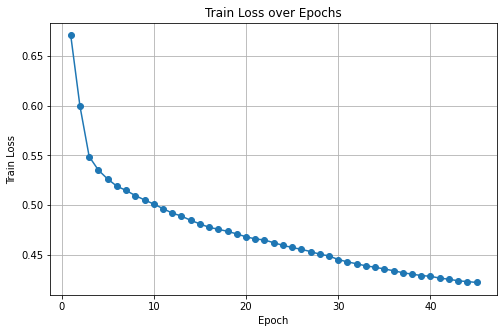

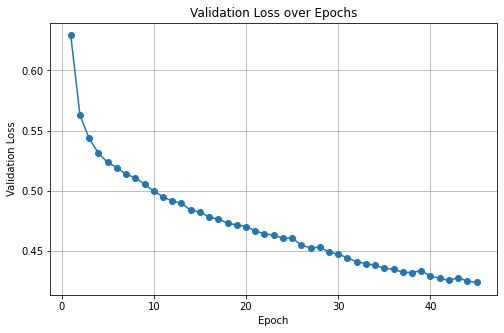

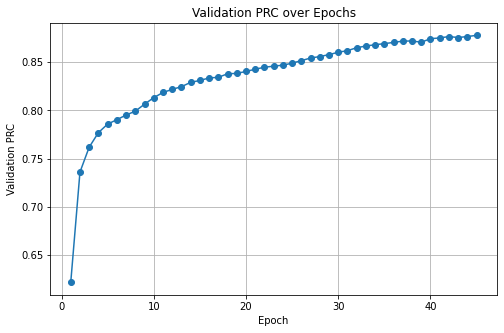

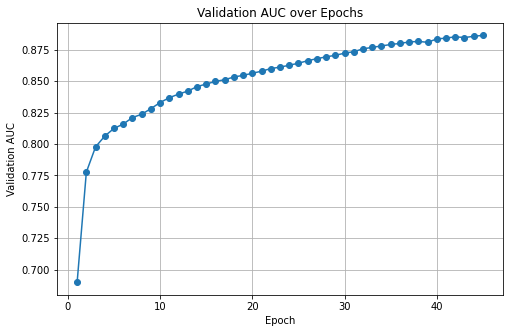

True


In [9]:
from tqdm import tqdm
from train import Trainer
from plot import plot_one_curve

reset_seed(seed)
# m = RGCNModel(in_feats, h_feats, out_feats, num_rels).to(device)
m = GATModel(in_feats, h_feats, out_feats, num_heads).to(device)
# m = HGTModel(in_feats, out_feats, num_heads, head_size, num_ntypes, num_rels).to(device)
# m.print_params()
reset_seed(seed)
trainer = Trainer(m,
                  # g,
                  # train_loader,
                  # test_loader,
                  # nn.BCEWithLogitsLoss(),
                  nn.BCELoss(),

                  lr=initial_lr,
                  scheduler_step_size=scheduler_step_size,
                  scheduler_gamma=scheduler_gamma,
                  threshold=scheduler_threshold)


prc_list = []
auc_list = []
train_loss_list = []
val_loss_list = []
for epoch in tqdm(range(num_epochs)):
    # loss,P = train_one_epoch()
    # 对于不变的情况
    loss, p1, p2, lr = trainer.train_one_epoch(train_loader, device)
    print(p1, p2)
    val_loss, prc, auc = trainer.evaluate(test_loader, device)
    prc_list.append(prc)
    auc_list.append(auc)
    train_loss_list.append(loss)
    val_loss_list.append(val_loss)
    print(f"Epoch {epoch+1}/{num_epochs}, Lr: {lr:.5f}, Train Loss: {loss:.4f}, Val Loss: {val_loss:.4f} Val prc: {prc:.4f}, Val auc: {auc:.4f}")

plot_one_curve(train_loss_list, "Train Loss", "Train Loss over Epochs")
plot_one_curve(val_loss_list, "Validation Loss", "Validation Loss over Epochs")

# === 绘制验证集 PRC/AUC 曲线 ===
plot_one_curve(prc_list, "Validation PRC", "Validation PRC over Epochs")
plot_one_curve(auc_list, "Validation AUC", "Validation AUC over Epochs")

base_prc_list = prc_list
base_auc_list = auc_list
base_train_loss_list = train_loss_list
base_val_loss_list = val_loss_list
print(torch.equal(keep_feat, g.ndata['feat']))

  0%|          | 0/45 [00:00<?, ?it/s]

0.5827819016251498 0.6161959071169179


  2%|▏         | 1/45 [00:15<11:17, 15.39s/it]

Epoch 1/45, Lr: 0.00100, Train Loss: 0.6706, Val Loss: 0.6288, Val prc: 0.6220, Val auc: 0.6900
0.69306953210298 0.7347929168884284


  4%|▍         | 2/45 [00:30<11:05, 15.48s/it]

...

Epoch 43/45, Lr: 0.00049, Train Loss: 0.3969, Val Loss: 0.3674, Val prc: 0.9129, Val auc: 0.9180
0.8933324479237282 0.9013334692527544


 98%|█████████▊| 44/45 [1:07:30<01:19, 79.75s/it]

Epoch 44/45, Lr: 0.00049, Train Loss: 0.3959, Val Loss: 0.3666, Val prc: 0.9138, Val auc: 0.9183
0.8936164919574484 0.9016657807438958


100%|██████████| 45/45 [1:08:10<00:00, 90.90s/it]

Epoch 45/45, Lr: 0.00034, Train Loss: 0.3952, Val Loss: 0.3641, Val prc: 0.9144, Val auc: 0.9187


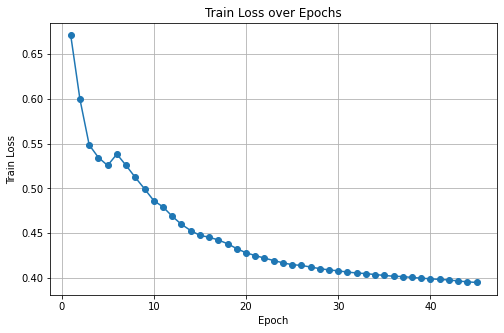

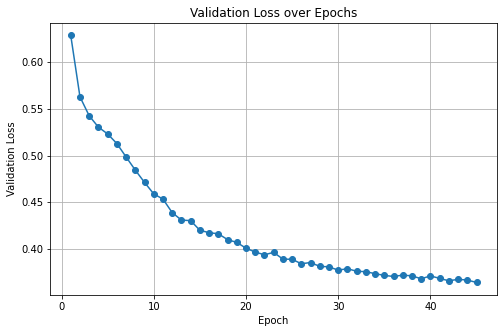

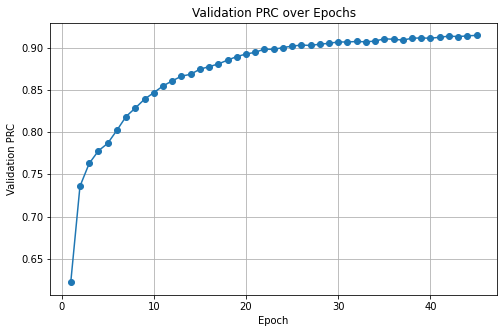

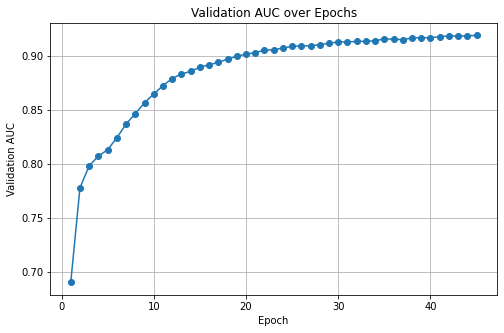

In [10]:
from sampler import  HardNegEdgeSampler, generate_hard_negative_edge_pool_fast

reset_seed(seed)
# m = RGCNModel(in_feats, h_feats, out_feats, num_rels).to(device)
m = GATModel(in_feats, h_feats, out_feats, num_heads).to(device)
# m = HGTModel(in_feats, out_feats, num_heads, head_size, num_ntypes, num_rels).to(device)
# m.print_params()
reset_seed(seed)

trainer = Trainer(m,
                  # g,
                  # train_loader,
                  # test_loader,
                  # nn.BCEWithLogitsLoss(),
                  nn.BCELoss(),

                  lr=initial_lr,
                  scheduler_step_size=scheduler_step_size,
                  scheduler_gamma=scheduler_gamma,
                  threshold=scheduler_threshold)


prc_list = []
auc_list = []
train_loss_list = []
val_loss_list = []
for epoch in tqdm(range(num_epochs)):
    # loss,P = train_one_epoch()
    if epoch % 5 == 0 and epoch >= 5:
        hard_neg_edge_pool = generate_hard_negative_edge_pool_fast(g, m, g.ndata['feat'], train_eids, top_k=3, device=device)

    if epoch >= 5:
        new_neg_sampler = HardNegEdgeSampler(
            neg_sampler,
            hard_neg_edge_pool,
            replace_ratio=0.1,
            )

        new_sampler = HomoGraphDataSampler(g, pos_sampler, new_neg_sampler)
        new_train_loader = new_sampler.construct_batch_data_sampler(train_eids, reverse_eids)
        loss, p1, p2, lr = trainer.train_one_epoch(new_train_loader, device)
    else:
        loss, p1, p2, lr = trainer.train_one_epoch(train_loader, device)
    print(p1, p2)
    val_loss, prc, auc = trainer.evaluate(test_loader, device)
    prc_list.append(prc)
    auc_list.append(auc)
    train_loss_list.append(loss)
    val_loss_list.append(val_loss)
    print(f"Epoch {epoch+1}/{num_epochs}, Lr: {lr:.5f}, Train Loss: {loss:.4f}, Val Loss: {val_loss:.4f}, Val prc: {prc:.4f}, Val auc: {auc:.4f}")


plot_one_curve(train_loss_list, "Train Loss", "Train Loss over Epochs")
plot_one_curve(val_loss_list, "Validation Loss", "Validation Loss over Epochs")

# === 绘制验证集 PRC/AUC 曲线 ===
plot_one_curve(prc_list, "Validation PRC", "Validation PRC over Epochs")
plot_one_curve(auc_list, "Validation AUC", "Validation AUC over Epochs")

## Compare

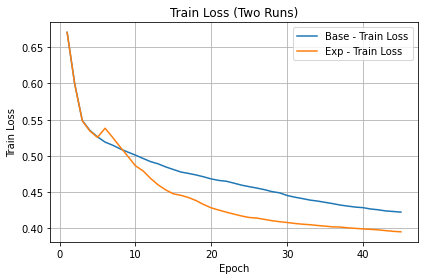

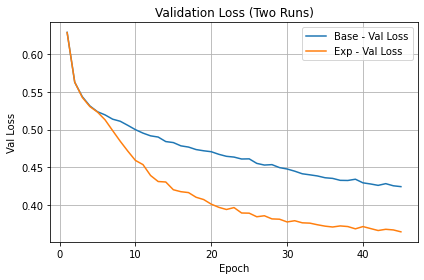

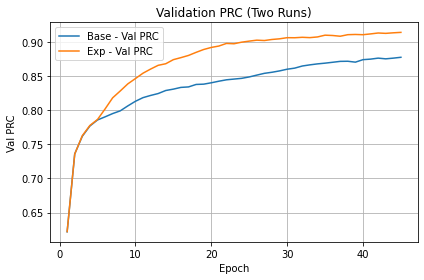

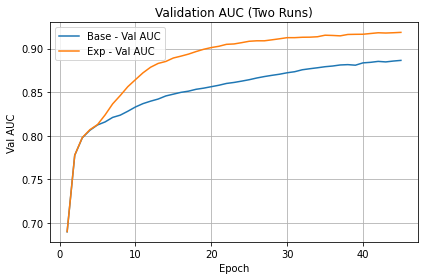

In [11]:
from plot import plot_two_curve

plot_two_curve(base_train_loss_list, train_loss_list,
               "Base - Train Loss", "Exp - Train Loss",
               "Train Loss", "Train Loss (Two Runs)")

plot_two_curve(base_val_loss_list, val_loss_list,
               "Base - Val Loss", "Exp - Val Loss",
               "Val Loss", "Validation Loss"
                           " (Two Runs)")

plot_two_curve(base_prc_list, prc_list,
               "Base - Val PRC", "Exp - Val PRC",
               "Val PRC", "Validation PRC (Two Runs)")

plot_two_curve(base_auc_list, auc_list,
               "Base - Val AUC", "Exp - Val AUC",
               "Val AUC", "Validation AUC (Two Runs)")
